<a href="https://colab.research.google.com/github/sreehariar04/test_new/blob/main/HR_Analytics_Sreehari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix


# ***Load Data***

In [3]:
train_data = pd.read_csv('/content/train_LZdllcl.csv')
train_data.head(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [5]:
train_data.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


## ***Check for null values***

In [6]:
train_data.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


## ***Handle Mising Values***

In [ ]:
train_data['previous_year_rating'].fillna(train_data['previous_year_rating'].median(), inplace=True)
train_data['education'].fillna(train_data['education'].mode()[0], inplace=True)
train_data.isnull().sum()

## ***encoding***

In [8]:
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']
print("Categorical columns identified for encoding:")
print(categorical_cols)

Categorical columns identified for encoding:
['department', 'region', 'education', 'gender', 'recruitment_channel']


In [9]:
train_data = pd.get_dummies(train_data, columns=categorical_cols, drop_first=True)

train_data.head()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,department_Finance,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,65438,1,35,5.0,8,1,0,49,0,False,...,False,False,True,False,False,False,True,False,False,True
1,65141,1,30,5.0,4,0,0,60,0,False,...,False,False,False,False,False,False,False,True,False,False
2,7513,1,34,3.0,7,0,0,50,0,False,...,False,False,False,False,False,False,False,True,False,True
3,2542,2,39,1.0,10,0,0,50,0,False,...,False,False,False,False,False,False,False,True,False,False
4,48945,1,45,3.0,2,0,0,73,0,False,...,False,False,False,False,False,False,False,True,False,False


## ***Scaling***

In [10]:
numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude 'employee_id' and 'is_promoted' from scaling
numerical_cols = [col for col in numerical_cols if col not in ['employee_id', 'is_promoted']]
numerical_cols

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
train_data[numerical_cols] = scaler.fit_transform(train_data[numerical_cols])

train_data[numerical_cols].head()

,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,-0.415276,0.025598,1.395766,0.500460,1.356878,-0.154018,-1.075931
1,-0.415276,-0.627135,1.395766,-0.437395,-0.736986,-0.154018,-0.253282
2,-0.415276,-0.104948,-0.250651,0.265996,-0.736986,-0.154018,-1.001145
3,1.226063,0.547785,-1.897069,0.969387,-0.736986,-0.154018,-1.001145
4,-0.415276,1.331064,-0.250651,-0.906322,-0.736986,-0.154018,0.718939


##***Train Test Split***

In [11]:
# Define features (X) and target (y)
X = train_data.drop(columns=['employee_id', 'is_promoted'])
y = train_data['is_promoted']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## ***Model Development***

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Baseline Random Forest
rf_baseline = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

# Train
rf_baseline.fit(X_train, y_train)

# Predict on validation set
y_pred = rf_baseline.predict(X_test)

# Evaluate
print("Baseline F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Baseline F1 score: 0.4423380726698262

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.84      0.30      0.44       934

    accuracy                           0.94     10962
   macro avg       0.89      0.65      0.70     10962
weighted avg       0.93      0.94      0.92     10962


Confusion Matrix:
 [[9976   52]
 [ 654  280]]


##***Hyper Parameter Tuning***

In [13]:
# Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Parameter search space
param_dist = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.7]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train tuning
random_search.fit(X_train, y_train)

# Best model
best_rf_model = random_search.best_estimator_

print("Best hyperparameters:", random_search.best_params_)
print("Best CV F1 score:", random_search.best_score_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': None}
Best CV F1 score: 0.4834834298102229


In [14]:
best_rf_model = random_search.best_estimator_
y_pred = best_rf_model.predict(X_test)
y_proba = best_rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9376
ROC AUC Score: 0.8880
F1 Score: 0.4993

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.79      0.37      0.50       934

    accuracy                           0.94     10962
   macro avg       0.87      0.68      0.73     10962
weighted avg       0.93      0.94      0.93     10962


Confusion Matrix:
[[9937   91]
 [ 593  341]]


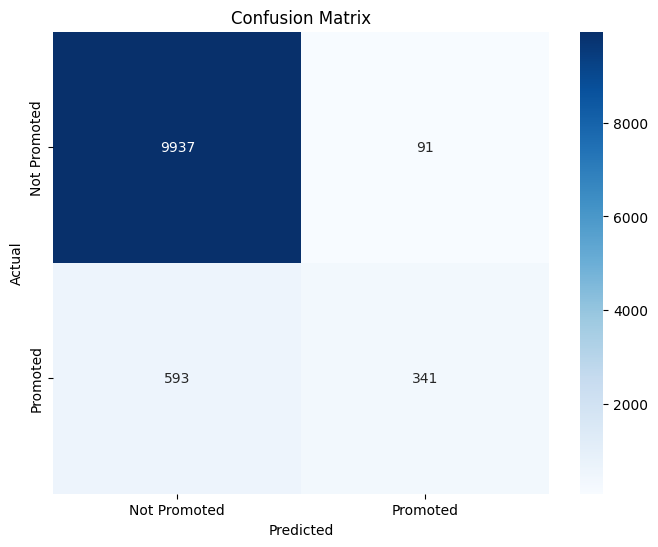

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Promoted', 'Promoted'], yticklabels=['Not Promoted', 'Promoted'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ***TESTING***

## Load Test Data




In [40]:
test_data = pd.read_csv('/content/test_2umaH9m.csv')
test_data.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [41]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


In [42]:
test_data.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
count,23490.000000,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000,23490.000000
mean,39041.399149,1.254236,34.782929,3.339146,5.810387,0.358834,0.022776,63.263133
std,22640.809201,0.600910,7.679492,1.263294,4.207917,0.479668,0.149191,13.411750
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19370.250000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,38963.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58690.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [43]:
test_data.isnull().sum()

,0
employee_id,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1812
length_of_service,0


## ***Handle Missing Values***

In [44]:
test_data['previous_year_rating'].fillna(test_data['previous_year_rating'].median(), inplace=True)
test_data['education'].fillna(test_data['education'].mode()[0], inplace=True)


/tmp/ipython-input-3028619571.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['previous_year_rating'].fillna(test_data['previous_year_rating'].median(), inplace=True)
/tmp/ipython-input-3028619571.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

In [45]:
test_data.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


##Encoding

In [46]:
categorical_cols = ['department', 'region', 'education', 'gender', 'recruitment_channel']
test_data = pd.get_dummies(test_data, columns=categorical_cols, drop_first=True)
test_data.head()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,department_Finance,department_HR,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,8724,1,24,3.0,1,1,0,77,False,False,...,False,False,False,False,False,False,False,True,False,True
1,74430,1,31,3.0,5,0,0,51,False,True,...,False,False,False,False,False,False,False,False,False,False
2,72255,1,31,1.0,4,0,0,47,False,False,...,False,False,False,False,False,False,False,True,False,False
3,38562,3,31,2.0,9,0,0,65,False,False,...,False,False,False,False,False,False,False,False,False,False
4,64486,1,30,4.0,7,0,0,61,True,False,...,False,False,False,False,False,False,False,True,False,True


## Scalingg

In [47]:
numerical_cols_test = test_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude 'employee_id' from scaling
numerical_cols_test = [col for col in numerical_cols_test if col not in ['employee_id']]

# Apply StandardScaler to the numerical columns using the already fitted scaler from training data
test_data[numerical_cols_test] = scaler.transform(test_data[numerical_cols_test])

test_data[numerical_cols_test].head()

,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,-0.415276,-1.410415,-0.250651,-1.140785,1.356878,-0.154018,1.018084
1,-0.415276,-0.496588,-0.250651,-0.202931,-0.736986,-0.154018,-0.926359
2,-0.415276,-0.496588,-1.897069,-0.437395,-0.736986,-0.154018,-1.225504
3,2.867403,-0.496588,-1.073860,0.734923,-0.736986,-0.154018,0.120649
4,-0.415276,-0.627135,0.572557,0.265996,-0.736986,-0.154018,-0.178496


## Prediction

In [48]:
X_test_processed = test_data.drop(columns=['employee_id'])

# Ensure the test data columns match the training data columns
missing_cols_in_test = set(X_train.columns) - set(X_test_processed.columns)
for col in missing_cols_in_test:
    X_test_processed[col] = 0  # Add missing columns with default value 0
X_test_processed = X_test_processed[X_train.columns] # Reorder columns to match X_train

print("Shape of X_test_processed:", X_test_processed.shape)
print("First 5 rows of X_test_processed:")
X_test_processed.head()

Shape of X_test_processed: (23490, 53)
First 5 rows of X_test_processed:


,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,department_Finance,department_HR,department_Legal,...,region_region_5,region_region_6,region_region_7,region_region_8,region_region_9,education_Below Secondary,education_Master's & above,gender_m,recruitment_channel_referred,recruitment_channel_sourcing
0,-0.415276,-1.410415,-0.250651,-1.140785,1.356878,-0.154018,1.018084,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,-0.415276,-0.496588,-0.250651,-0.202931,-0.736986,-0.154018,-0.926359,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.415276,-0.496588,-1.897069,-0.437395,-0.736986,-0.154018,-1.225504,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,2.867403,-0.496588,-1.073860,0.734923,-0.736986,-0.154018,0.120649,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.415276,-0.627135,0.572557,0.265996,-0.736986,-0.154018,-0.178496,True,False,False,...,False,False,False,False,False,False,False,True,False,True


In [49]:
test_predictions = best_rf_model.predict(X_test_processed)
test_probabilities = best_rf_model.predict_proba(X_test_processed)[:, 1]

In [50]:
submission = pd.DataFrame({
    'employee_id': test_data['employee_id'],
    'is_promoted': test_predictions
})

submission.to_csv('submission.csv', index=False)
